# Population Omega

Using the [human mortality database](https://www.mortality.org/Country/Country?cntr=USA) mortality rates, calculating the GLM omega rates

The data does include female, male, total qx from 1933 - 2023

A simple logistic regression will not fit the curve perfectly as there can be non-linear relationships with the shape of the curve. A spline is a good method to be able to model non-linear relationship as the mortality rates generally tend to accelerate and decelerate at different ages. It is recommended to use 3 degrees to represent gradual changes and somewhere between 3-5 knots.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import polars as pl

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
from morai import models
from morai.models import r
from morai.experience import charters, tables
from morai.forecast import metrics, preprocessors
from morai.integrations import hmd
from morai.utils import custom_logger, helpers

In [3]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

# Data

In [4]:
db_filepath = r"files/integrations/hmd/hmd.sql"

In [5]:
hmd_usa_df = hmd.get_hmd_data_sql(db_filepath=db_filepath, table_name='hmd')

In [6]:
hmd_usa_df = hmd_usa_df[(hmd_usa_df["year"] >= 1950) & (hmd_usa_df["year"] <= 2023)]
hmd_usa_df["qx_raw"] = hmd_usa_df["total_death"] / hmd_usa_df["total_exposure"]

In [7]:
preprocess_dict = preprocessors.preprocess_data(
    hmd_usa_df,
    feature_dict={
        "target": ["qx_raw"],
        "weight": [],
        "passthrough": [
            "year",
            "age",
        ],
    },
    standardize=False,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2025-11-27 13:17:04 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2025-11-27 13:17:04 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-11-27 13:17:04 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'year', 'constant'] 


# Models

## GLM

In [8]:
GLM = models.core.GLM()
GLM.fit(X, y)

 2025-11-27 13:17:04 | morai.models.core | INFO     | fiting the model 
 2025-11-27 13:17:04 | morai.models.core | INFO     | setup GLM model with statsmodels and <statsmodels.genmod.families.family.Binomial object at 0x0000025D675D75C0> family... 


In [10]:
hmd_usa_df["glm"] = GLM.predict(X)

## GAM

In [11]:
GAMR = r.GAMR()
spline_dict = {
    "age": {"bs":"tp"},
}

In [12]:
GAMR.setup_model(X=X, y=y, weights=weights, spline_dict=spline_dict)

 2025-11-27 13:17:11 | morai.models.r | INFO     | setup GAM model with mgcv and `quasibinomial` distribution with `logit` link 
 2025-11-27 13:17:16 | morai.models.r | INFO     | formula: 
 2025-11-27 13:17:16 | morai.models.r | INFO     | > qx_raw ~ s(`age`, bs='tp')+`constant`+`year` 
 2025-11-27 13:17:17 | morai.models.r | INFO     | fitting the model: 
 2025-11-27 13:17:17 | morai.models.r | INFO     | > model <- bam(formula, data=data, weights=weights, family=family, drop.intercept=TRUE)` 
 2025-11-27 13:17:18 | morai.models.r | INFO     | model fitted 


In [13]:
print(GAMR.summary(expand=True))

Generalized Additive Model (mgcv) Summary
Family                : quasibinomial
Link                  : logit
Number of Observations: 8214
Adjusted R-squared    : 0.931
Deviance Explained    : 96.3%
Scale Estimate        : 0.00808
fREML                 : -8090

Formula:
qx_raw ~ s(`age`, bs='tp')+`constant`+`year`

Parametric Coefficients:
constant   -12.288800
year         0.003983

Smooth Terms:
             edf    Ref.df            F  p-value     alpha
s(age)  8.941999  8.998176  9781.939908      0.0  0.000033

Expanded Smooth Terms:
        name       coef
2   s(age).1 -13.648854
3   s(age).2   4.235869
4   s(age).3   4.602604
5   s(age).4  -1.772755
6   s(age).5  -1.787473
7   s(age).6   2.045635
8   s(age).7  -1.718781
9   s(age).8  -1.255486
10  s(age).9  -6.055611


In [14]:
hmd_usa_df["gam"] = GAMR.predict(X)

 2025-11-27 13:17:18 | morai.models.r | INFO     | predicted rates 


# Compare

In [15]:
hmd_usa_df[hmd_usa_df['age']>=100]['total_death'].sum()

np.float64(924036.03)

In [16]:
hmd_usa_df[hmd_usa_df['age']>=100]['total_exposure'].sum()

np.float64(2091478.1400000001)

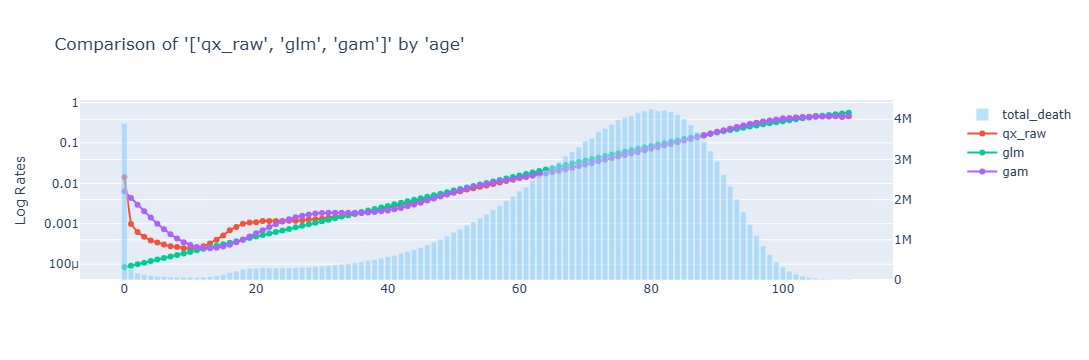

In [18]:
charters.compare_rates(
    df=hmd_usa_df,
    x_axis="age",
    rates=["qx_raw", "glm", "gam"],
    secondary="total_death",
    display=True,
    y_log=True,
)

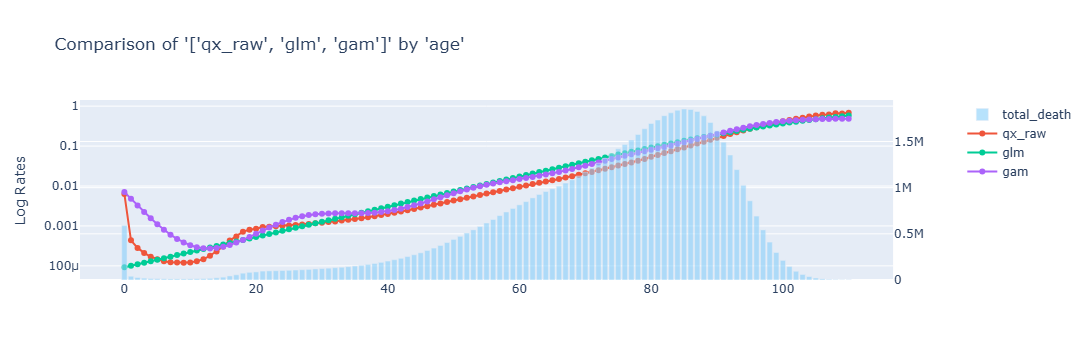

In [19]:
charters.compare_rates(
    df=hmd_usa_df[hmd_usa_df['year']>=2000],
    x_axis="age",
    rates=["qx_raw", "glm", "gam"],
    secondary="total_death",
    display=True,
    y_log=True,
)